# 02 — Modélisation : prédiction de panne dans les 30 jours

Objectif : à partir des mesures capteurs (température, vibration, usure...),
prédire si un équipement va tomber en panne dans les 30 prochains jours
(`panne_30j`, cible binaire).


In [1]:
import sys
sys.path.insert(0, "..")

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

from src.modeling import train_and_evaluate, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

def show_image(path):
    """Affiche une image PNG dans le notebook (utilise matplotlib plutôt
    que IPython.display.Image pour ne dépendre que de bibliothèques déjà
    listées dans requirements.txt)."""
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.axis("off")
    plt.show()


## 1. Chargement des données nettoyées

In [3]:
df = pd.read_csv("../data/processed/panne_equipement_clean.csv")
print(df.shape)
df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].head()


(900, 14)


In [4]:
df[TARGET].value_counts(normalize=True)


## 2. Entraînement et évaluation

Méthodologie :
- Split train/test 80/20, **stratifié** sur la cible, `random_state=42`.
- Préprocesseur (standardisation + one-hot) ajusté **uniquement sur le
  train**, appliqué ensuite au test (pas de fuite de données).
- Deux modèles comparés par validation croisée (5 folds, ROC-AUC) :
  régression logistique et forêt aléatoire, tous deux avec
  `class_weight="balanced"` pour gérer le déséquilibre (~19% de pannes).
- Le meilleur modèle en validation croisée est réévalué sur le jeu de test
  tenu à l'écart.


In [6]:
results = train_and_evaluate(df, Path("../outputs"))
print(json.dumps(results, indent=2, ensure_ascii=False))


{
  "modele_selectionne": "random_forest",
  "cv_roc_auc_par_modele": {
    "logistic_regression": {
      "roc_auc_mean": 0.761870767234752,
      "roc_auc_std": 0.03726546811688961
    },
    "random_forest": {
      "roc_auc_mean": 0.7626652172150257,
      "roc_auc_std": 0.03682286984263376
    }
  },
  "test_roc_auc": 0.7860596293311845,
  "classification_report": {
    "0": {
      "precision": 0.8627450980392157,
      "recall": 0.9041095890410958,
      "f1-score": 0.882943143812709,
      "support": 146.0
    },
    "1": {
      "precision": 0.48148148148148145,
      "recall": 0.38235294117647056,
      "f1-score": 0.4262295081967213,
      "support": 34.0
    },
    "accuracy": 0.8055555555555556,
    "macro avg": {
      "precision": 0.6721132897603486,
      "recall": 0.6432312651087833,
      "f1-score": 0.6545863260047151,
      "support": 180.0
    },
    "weighted avg": {
      "precision": 0.790728637133866,
      "recall": 0.8055555555555556,
      "f1-score": 0.7966

## 3. Visualisations des résultats

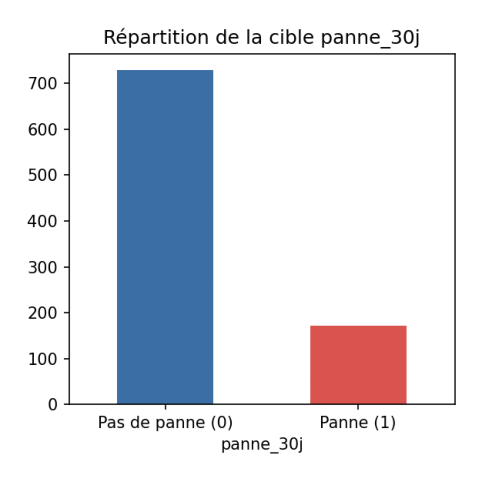

In [8]:
show_image("../outputs/figures/target_distribution.png")


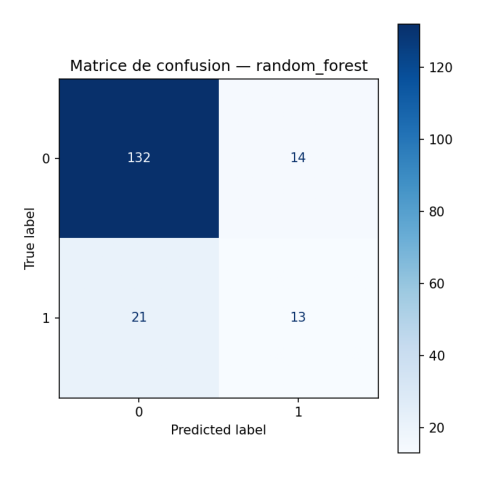

In [9]:
show_image("../outputs/figures/confusion_matrix.png")


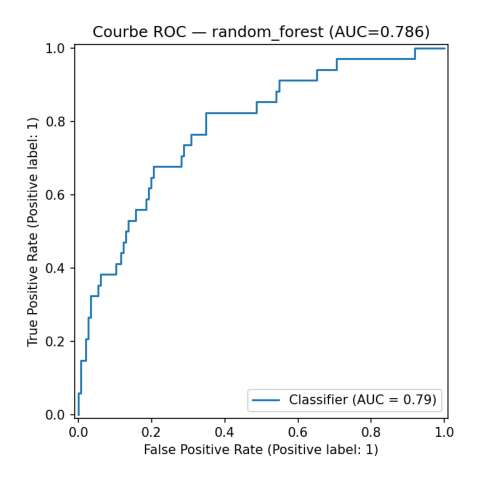

In [10]:
show_image("../outputs/figures/roc_curve.png")


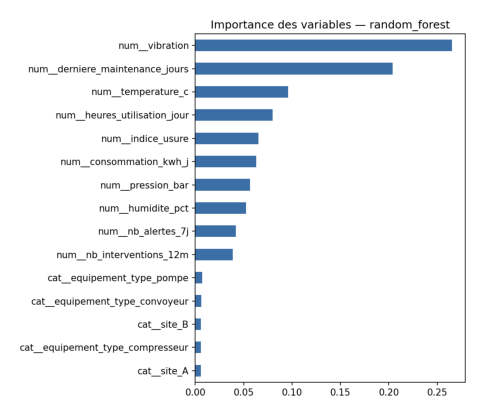

In [11]:
show_image("../outputs/figures/feature_importance.png")


## 4. Lecture des résultats

- Le modèle retenu obtient un **ROC-AUC ≈ 0.79** sur le jeu de test tenu à
  l'écart — nettement mieux que le hasard (0.5), sur un jeu de données
  synthétique volontairement bruité.
- Les variables les plus prédictives sont la **vibration**, le nombre de
  jours depuis la **dernière maintenance** et la **température** — cohérent
  avec l'intuition métier (usure mécanique + carence de maintenance).
- Le rappel sur la classe "panne" (minoritaire) reste modéré : c'est attendu
  vu le déséquilibre de classes et le bruit du jeu de données pédagogique.
  Sur des données réelles, on chercherait à améliorer le rappel (quitte à
  sacrifier de la précision), car manquer une panne coûte plus cher qu'une
  fausse alerte.

## 5. Limites & pistes d'amélioration
- Jeu de données synthétique et petit (900 lignes) : les résultats sont
  illustratifs, pas un modèle de production.
- Pas de recherche d'hyperparamètres poussée (`GridSearchCV`/`Optuna`)
  pour rester dans un temps d'exécution raisonnable pour ce portfolio.
- Ajouter du feature engineering temporel si des données de séries
  temporelles par équipement étaient disponibles (au lieu d'un instantané).
